In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
from pathlib import Path
from typing import Dict, Tuple, Optional, Union, Any, List
import warnings
import scanpy as sc
warnings.filterwarnings('ignore')

# Import additional libraries for neural network training
from sklearn.model_selection import train_test_split, StratifiedKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, average_precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input, Add, Activation, 
    MultiHeadAttention, LayerNormalization, Reshape, Flatten,
    GlobalAveragePooling1D, Embedding
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras import backend as K
from sklearn.ensemble import RandomForestClassifier

In [2]:
ref_data = pd.read_csv('./smart_aligned_v2_dataset_reference_5_to_1.csv')
ref_data

,tcr,peptide,label,tcr_source_dataset,tcr_source_index,peptide_source_dataset,peptide_source_index,donor,binding_tcr
0,CASSLYEQYF,GILGFVFTL,1,10X,0,10X,0,donor1,Y
1,CAWTGTGKIGWDSPLHF,KLGGALQAK,1,10X,2,10X,2,donor1,Y
2,CASSWGGGSHYGYTF,IVTDFSVIK,1,10X,3,10X,3,donor1,Y
3,CASSLYSATGELFF,AVFDRKSDAK,1,10X,5,10X,5,donor1,Y
4,CASSLYSATGELFF,AVFDRKSDAK,1,10X,6,10X,6,donor1,Y
...,...,...,...,...,...,...,...,...,...
431041,CASSFGRGEGEQYF,ELAGIGILTV,0,10X,39940,10X,258,NaN,N
431042,CASSPHFQVDTGELFF,IVTDFSVIK,0,10X,85427,10X,3,NaN,Y
431043,CASSLMRGGTYNSPLHF,FLYALALLL,0,10X,72515,10X,134,NaN,N
431044,CASSVSSTDTQYF,GILGFVFTL,0,10X,133931,10X,0,NaN,Y


In [3]:
ref_data['label'].value_counts(normalize = True)

label
0    0.833333
1    0.166667
Name: proportion, dtype: float64

In [4]:
get_10_X_dat = sc.read_h5ad('../data/merge_gex_all_donors_all_peptides_meta_for_Leah_dat.h5ad')

In [5]:
get_10_X_dat.obs['antigen'].value_counts()

antigen
unknown                                    73638
A0301_KLGGALQAK_IE-1_CMV_binder            31301
B0801_RAKFKQLL_BZLF1_EBV_binder            19941
A0201_GILGFVFTL_Flu-MP_Influenza_binder     8867
A1101_IVTDFSVIK_EBNA-3B_EBV_binder          4920
A1101_AVFDRKSDAK_EBNA-3B_EBV_binder         4250
A0201_GLCTLVAML_BMLF1_EBV_binder            1618
A0301_RLRAEAQVK_EMNA-3A_EBV_binder           460
A0201_ELAGIGILTV_MART-1_Cancer_binder        311
A0201_FLYALALLL_LMP2A_EBV_binder             173
Name: count, dtype: int64

In [6]:
get_10_X_dat

AnnData object with n_obs × n_vars = 145479 × 5000
    obs: 'v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA', 'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB', 'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b', 'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV', 'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer', 'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer', 'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer', 'A0201_KVLEYVIKV_MAGE-A1_Cancer', 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase', 'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91', 'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV', 'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza', 'A0201_GLCTLVAML_BMLF1_EBV', 'A0201_NLVPMVATV_pp65_CMV', 'A0201_I

In [7]:
donor = get_10_X_dat.obs['donor'].reset_index(drop=True )
donor = pd.get_dummies(donor, prefix='donor') +0
donor

,donor_donor1,donor_donor2,donor_donor3,donor_donor4
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0
...,...,...,...,...
145474,0,0,0,1
145475,0,0,0,1
145476,0,0,0,1
145477,0,0,0,1


In [8]:
ref_gex = get_10_X_dat[ref_data['tcr_source_index'].values,:]
gex = ref_gex.X.toarray()

In [9]:
obs = get_10_X_dat.obs.copy()
obs = obs.reset_index().reset_index().rename(
    columns={'index': 'tcr_source_index'}  # this 'tcr_source_index' should match ref_data
)

obs_lookup = obs[['tcr_source_index', 'donor']]

ref_merged = ref_data.merge(
    obs_lookup,
    on='tcr_source_index',
    how='left',
    suffixes=('', '_from_obs')
)

ref_merged['donor'] = ref_merged['donor'].fillna(ref_merged['donor_from_obs'])
ref_merged = ref_merged.drop(columns=['donor_from_obs'])
ref_merged

,tcr,peptide,label,tcr_source_dataset,tcr_source_index,peptide_source_dataset,peptide_source_index,donor,binding_tcr
0,CASSLYEQYF,GILGFVFTL,1,10X,0,10X,0,donor1,Y
1,CAWTGTGKIGWDSPLHF,KLGGALQAK,1,10X,2,10X,2,donor1,Y
2,CASSWGGGSHYGYTF,IVTDFSVIK,1,10X,3,10X,3,donor1,Y
3,CASSLYSATGELFF,AVFDRKSDAK,1,10X,5,10X,5,donor1,Y
4,CASSLYSATGELFF,AVFDRKSDAK,1,10X,6,10X,6,donor1,Y
...,...,...,...,...,...,...,...,...,...
431041,CASSFGRGEGEQYF,ELAGIGILTV,0,10X,39940,10X,258,donor2,N
431042,CASSPHFQVDTGELFF,IVTDFSVIK,0,10X,85427,10X,3,donor2,Y
431043,CASSLMRGGTYNSPLHF,FLYALALLL,0,10X,72515,10X,134,donor2,N
431044,CASSVSSTDTQYF,GILGFVFTL,0,10X,133931,10X,0,donor3,Y


In [15]:
pd.read_csv('10X_data_pca_harmony_batch_correction_by_donor_embeddings.csv', index_col=0)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1.087143,0.467443,2.992532,-0.600697,-3.994596,-3.333098,1.494854,-1.146100,1.571670,-3.118363,...,-0.210213,1.269835,0.131614,1.555858,-0.562283,0.154132,1.219355,-0.089831,-0.300811,0.098589
1,9.246613,-4.383909,-4.804466,-0.070527,1.494315,0.910335,2.323131,-1.229502,-1.463696,1.459822,...,0.890217,0.616105,-0.418397,0.040113,-0.075964,0.261941,1.278015,0.778815,-0.413370,0.533625
2,-4.378371,1.180819,-4.223704,-5.470704,0.444927,-0.000247,1.059516,0.668836,0.961870,1.295324,...,1.722274,0.045716,0.730128,1.226174,1.399147,-0.674245,0.482494,0.890334,-1.046426,-0.332977
3,-0.850734,5.800984,2.319241,0.621932,0.391961,1.471914,-1.820410,-1.887836,0.645741,-0.318717,...,-0.187072,0.493142,-0.507019,-0.700821,-0.482881,1.702497,-2.204038,0.750383,2.090266,-0.414377
4,7.510671,-3.492533,0.615445,-0.826791,-0.356948,-0.733857,-0.747724,-1.670011,-0.794903,-0.049055,...,0.420621,0.245370,-0.644681,-0.188387,-0.635079,0.767439,1.157366,0.416946,0.140676,-0.130281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145474,-0.928211,4.903222,-2.795438,-2.711269,-0.354280,-0.522040,-0.471457,-2.239837,-0.942964,0.537984,...,1.706733,-0.141238,1.290803,0.571046,2.032877,-0.091293,-2.120174,2.326794,-0.270818,2.348335
145475,-3.711599,5.466145,-1.662588,3.397898,-1.352260,2.653984,1.317506,2.093558,-0.908551,-1.140238,...,-0.622839,-0.013557,-0.371825,0.784568,-0.067285,-0.820746,-0.442909,-0.638775,-0.235357,-0.845757
145476,-0.427704,-4.652079,0.408053,-1.942324,-2.452670,2.487576,-1.482361,-0.260748,-0.498160,0.732487,...,0.760570,0.456670,-0.208458,-0.142902,-0.938427,0.216794,1.042893,-0.465932,-0.601186,0.570299
145477,7.317558,-4.430610,1.243477,0.069994,0.100587,-1.188651,-0.900679,-0.003285,-0.333207,-0.494998,...,1.442170,0.210964,0.092243,0.610511,-0.685681,-0.969873,-0.389187,0.062457,-0.254924,-0.485812


In [10]:
batch_gex = pd.read_csv('10X_data_pca_harmony_batch_correction_by_donor_embeddings.csv', index_col=0)
batch_gex = batch_gex.loc[ref_merged['tcr_source_index'].values]
batch_gex

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1.087143,0.467443,2.992532,-0.600697,-3.994596,-3.333098,1.494854,-1.146100,1.571670,-3.118363,...,-0.210213,1.269835,0.131614,1.555858,-0.562283,0.154132,1.219355,-0.089831,-0.300811,0.098589
2,-4.378371,1.180819,-4.223704,-5.470704,0.444927,-0.000247,1.059516,0.668836,0.961870,1.295324,...,1.722274,0.045716,0.730128,1.226174,1.399147,-0.674245,0.482494,0.890334,-1.046426,-0.332977
3,-0.850734,5.800984,2.319241,0.621932,0.391961,1.471914,-1.820410,-1.887836,0.645741,-0.318717,...,-0.187072,0.493142,-0.507019,-0.700821,-0.482881,1.702497,-2.204038,0.750383,2.090266,-0.414377
5,-0.790633,-0.208497,-1.233520,2.680560,1.708483,0.613669,-1.287696,0.153485,-0.021906,-0.508320,...,-0.138782,-0.516450,1.391405,0.140142,-0.495096,0.871033,-0.136164,0.289218,-0.143441,-0.316246
6,-0.529419,-0.319814,-2.077449,2.748021,1.083930,0.285122,-1.394146,-1.113498,1.634049,-2.110551,...,-0.390809,1.235467,-0.210995,0.477084,0.740880,1.041670,0.724317,-1.486853,0.464953,-1.606659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39940,7.258466,-0.441589,2.434735,-0.982661,3.171575,-1.031945,-0.036376,0.710349,0.554951,-0.457027,...,1.366947,0.849124,-1.220757,0.431438,0.195378,0.720444,-1.507882,0.140615,0.591948,0.615716
85427,-0.054112,-0.484272,-3.879627,2.657925,-0.414311,0.704270,0.340468,1.743991,1.232210,-1.462541,...,0.480002,1.074384,-0.219597,0.765565,-0.607775,1.176836,-0.159022,-0.363572,0.248886,-1.012568
72515,-3.142024,5.825717,-0.870645,4.516282,-1.533534,-1.416487,0.271196,-0.076148,-0.698793,1.070387,...,-0.544055,0.813263,0.384533,-0.220888,-1.503408,0.206049,-0.815643,-0.594249,0.324401,-1.085030
133931,5.932758,8.369378,6.578253,-0.004961,0.567528,-2.646550,1.318340,2.293685,-0.549385,-0.075498,...,-0.535247,1.765181,-0.998657,0.116376,0.174009,-0.188104,0.911411,-0.613282,-0.914758,-0.493667


In [11]:
donor = donor.loc[ref_merged['tcr_source_index'].values]

In [12]:
donor

,donor_donor1,donor_donor2,donor_donor3,donor_donor4
0,1,0,0,0
2,1,0,0,0
3,1,0,0,0
5,1,0,0,0
6,1,0,0,0
...,...,...,...,...
39940,0,1,0,0
85427,0,1,0,0
72515,0,1,0,0
133931,0,0,1,0


# We make inference prediction on the resulst by TCR split and random split

# We prediction from TCR split for AE model

## Integration batch gene and TCRs

## With NO VDJ gene

### Load Apexigen results of encoding

In [13]:
ED_integration_gex_tcr = np.load(f"ED_integration_batch_gex_tcr_embeddings_train_Apexigen.npy" )
ED_integration_gex_tcr.shape

(16286, 64)

### Load interested peptide encoding (tumor antigen peptides)

In [14]:
embeddings_peptide_PE = np.load(f"train_peptide_with_PE_and_AE_embeddings_all_peptide_IEDB_McPAS_VDJdb.npy")
embeddings_peptide_PE.shape

(1147, 50)

### We create all possible pair of T-cells TCR with genes and peptides of interest

In [15]:
ED_integration_gex_tcr

array([[ 0.09796494, -5.5649886 ,  0.68114233, ..., -0.7965908 ,
         4.7925587 ,  1.5970128 ],
       [ 0.22861767, -1.1838733 ,  1.7441229 , ...,  2.6209605 ,
         1.1325388 ,  0.6274084 ],
       [-0.07723123, -2.486963  ,  0.5723655 , ...,  3.0070934 ,
         1.4912853 ,  1.4028907 ],
       ...,
       [-1.7042607 , -3.8924236 ,  1.2299587 , ...,  1.7613738 ,
         3.4404616 , -1.4602307 ],
       [ 0.05148342, -1.6596868 , -0.8989651 , ...,  0.811334  ,
         1.8953612 ,  0.46753174],
       [-1.7611202 , -6.4924464 , -2.4614675 , ...,  0.92895603,
         3.5968945 , -0.17681819]], dtype=float32)

In [16]:
ED_integration_gex_tcr_peptide_times = np.tile(ED_integration_gex_tcr, (embeddings_peptide_PE.shape[0],1))
embeddings_peptide_PE_TCR_times = np.tile(embeddings_peptide_PE, (ED_integration_gex_tcr.shape[0],1))

In [17]:
embeddings_peptide_PE_TCR_times

array([[3.7633004 , 5.3476014 , 3.54986   , ..., 8.317769  , 5.8649526 ,
        6.3339367 ],
       [3.5039241 , 6.2617354 , 0.450256  , ..., 3.0788279 , 0.93254876,
        5.3684797 ],
       [1.6825045 , 3.158739  , 1.3040373 , ..., 1.9804212 , 1.0794393 ,
        3.3869245 ],
       ...,
       [5.1576047 , 4.4608965 , 1.6875317 , ..., 2.1335058 , 1.8513671 ,
        3.4870389 ],
       [4.3051677 , 7.287125  , 3.6169248 , ..., 3.5910354 , 1.846532  ,
        2.3825283 ],
       [8.284342  , 6.868283  , 5.90911   , ..., 3.271999  , 4.0421023 ,
        2.424671  ]], dtype=float32)

In [18]:
ED_integration_gex_tcr_peptide_times.shape, embeddings_peptide_PE_TCR_times.shape

((18680042, 64), (18680042, 50))

### Pairwise TCR integration and peptide for prediction

In [19]:
inferencce_input = np.concatenate((ED_integration_gex_tcr_peptide_times, embeddings_peptide_PE_TCR_times), axis=1)

In [20]:
inferencce_input.shape

(18680042, 114)

In [21]:
IEDB_McPAS_VDJdb_Epitope = pd.read_csv('./Merged_IEDB_McPAS_VDJdb_TCR_peptide_peptide_type_TCR_peptide_pair_unique.csv')
Apexigen_meta = pd.read_csv('./Apexigen_data/Apexigen_obs_metadata_for_integration_real_case.csv', index_col=0)
Apexigen_meta

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3
AAACCTGAGGCGCTCT-1-4,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF
AAACCTGCATGCCACG-1-4,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF
AAACCTGTCTCCTATA-1-6,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,0.055342,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF
AAACGGGAGGGATACC-1-8,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF
AAACGGGCATCGGAAG-1-3,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCCTCCACTCGACG-1_05_post,0,4706.0,1357,PD,05,pathCR,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF
TTTGCGCGTGTGCCTG-1_05_post,0,2891.0,1380,PD,05,pathCR,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF
TTTGGTTCACCAGCAC-1_05_post,0,3474.0,1338,PD,05,pathCR,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF
TTTGGTTGTTCTGGTA-1_05_post,0,4632.0,1231,PD,05,pathCR,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF


In [22]:
IEDB_McPAS_VDJdb_Epitope

,Unnamed: 0,CDR3,Epitope
0,1,CASSYVGNTGELFF,SLLMWITQC
1,2,CAISEVGVGQPQHF,AAGIGILTV
2,4,CAISEVGVGQPQHF,ELAGIGILTV
3,5,ASSFIGGTDTQYF,YLEPGPVTV
4,6,ASSFIGGTDTQYFG,YLEPGAVTA
...,...,...,...
48179,40081,CSAGTGELFF,ALDPHSGHFV
48180,40082,CSARVGDTGELFF,ALSPVIPHI
48181,40083,CASSYDSTTGELFF,ALSPVIPHI
48182,40084,CASTPGGYEQYF,KLFEFLVYGV


In [23]:
IEDB_McPAS_VDJdb_Epitope

,Unnamed: 0,CDR3,Epitope
0,1,CASSYVGNTGELFF,SLLMWITQC
1,2,CAISEVGVGQPQHF,AAGIGILTV
2,4,CAISEVGVGQPQHF,ELAGIGILTV
3,5,ASSFIGGTDTQYF,YLEPGPVTV
4,6,ASSFIGGTDTQYFG,YLEPGAVTA
...,...,...,...
48179,40081,CSAGTGELFF,ALDPHSGHFV
48180,40082,CSARVGDTGELFF,ALSPVIPHI
48181,40083,CASSYDSTTGELFF,ALSPVIPHI
48182,40084,CASTPGGYEQYF,KLFEFLVYGV


In [24]:
Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope = pd.read_csv("./Apexigen_match_IEDB_McPAS_VDJdb_all_data.csv")
Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope = Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope[['TRB_cdr3','Epitope']].drop_duplicates()
Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope['TCR_Epitope_pair'] = Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope['TRB_cdr3'] + '_' + Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope['Epitope']
Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope

,TRB_cdr3,Epitope,TCR_Epitope_pair
0,CASSLSVYEQYF,LPRRSGAAGA,CASSLSVYEQYF_LPRRSGAAGA
1,CASSLSGLAGGYEQYF,EAAGIGILTV,CASSLSGLAGGYEQYF_EAAGIGILTV
2,CASSPGLAGGEQYF,FLAEHEYGL,CASSPGLAGGEQYF_FLAEHEYGL
3,CASRPGGGSYNEQFF,RLGPYLEFL,CASRPGGGSYNEQFF_RLGPYLEFL
4,CATSRVAGETQYF,FRCPRRFCF,CATSRVAGETQYF_FRCPRRFCF
...,...,...,...
281,CASSLGGSTDTQYF,PQPELPYPQPE,CASSLGGSTDTQYF_PQPELPYPQPE
283,CASSPPRQETQYF,HLKRNIVV,CASSPPRQETQYF_HLKRNIVV
284,CASSPGYEQYF,GLCTLVAML,CASSPGYEQYF_GLCTLVAML
288,CASSLQGSYEQYF,VVMSWAPPV,CASSLQGSYEQYF_VVMSWAPPV


In [25]:

peptide_list = pd.read_csv("./All_epitope_IEDB_McPAS_VDJdb.csv", index_col=0).reset_index(drop=True)
peptide_list

,Epitope
0,SLLMWITQC
1,AAGIGILTV
2,ELAGIGILTV
3,YLEPGPVTV
4,YLEPGAVTA
...,...
1142,QLCDVMFYL
1143,YLYDRLLRV
1144,LYPEFIASI
1145,MLIGIPVYV


In [26]:

repeated_Apexigen_meta = pd.concat([Apexigen_meta] * peptide_list.shape[0], ignore_index=True)
repeated_IEDB_tumor_epitope = pd.concat([peptide_list] * Apexigen_meta.shape[0], ignore_index=True)
Apexigen_tumor_paired = pd.concat([repeated_Apexigen_meta, repeated_IEDB_tumor_epitope], axis=1)
Apexigen_tumor_paired



,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope
0,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,SLLMWITQC
1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,AAGIGILTV
2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,0.055342,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,ELAGIGILTV
3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,YLEPGPVTV
4,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,YLEPGAVTA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18680037,0,4706.0,1357,PD,05,pathCR,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF,QLCDVMFYL
18680038,0,2891.0,1380,PD,05,pathCR,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF,YLYDRLLRV
18680039,0,3474.0,1338,PD,05,pathCR,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF,LYPEFIASI
18680040,0,4632.0,1231,PD,05,pathCR,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF,MLIGIPVYV


In [27]:
Apexigen_tumor_paired['TCR_Epitope_pair'] = Apexigen_tumor_paired['TRB_cdr3'] + '_' + Apexigen_tumor_paired['Epitope']
Apexigen_tumor_paired_match_IEDB = Apexigen_tumor_paired[Apexigen_tumor_paired.TCR_Epitope_pair.isin(Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope.TCR_Epitope_pair.values)].copy()

In [28]:
Apexigen_tumor_paired.iloc[[655528]]

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
655528,42,2225.0,874,HD,HD_01,HD,HD_03,NaN,7.707512,0.066966,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGTGSTDTQYF,CAVLNNDMRF,LLFGMTPCL,CASSLGTGSTDTQYF_LLFGMTPCL


In [29]:
Apexigen_tumor_paired_match_IEDB

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
118541,38,3612.0,1457,CR,03,pathCR,03_surgery,surgery,8.192017,0.041805,12,CD8T,CD8T_GrH1,CD8T_prolif,CD8_T,CATSREGGETQYF,CATERDFGNEKLTF,FRCPRRFCF,CATSREGGETQYF_FRCPRRFCF
138116,0,5787.0,1960,NaN,02,pathCR,02_post,post_CD40,8.663369,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,CASSGDGMNTEAFF_FLYALALLL
164403,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,RPHERNGFTVL,CASSPSRNTEAFF_RPHERNGFTVL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18306508,9,1581.0,758,PD,01,nopathCR,01_pre,pre_CD40,7.365813,0.067046,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSYSSGELFF,CALSEAGYSGYALNF,LPRRSGAAGA,CASSYSSGELFF_LPRRSGAAGA
18322566,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,LPRRSGAAGA,CAWKASGNTIYF_LPRRSGAAGA
18413179,0,1981.0,995,CR,03,pathCR,03_pre,pre_CD40,7.591357,0.000000,3,CD8_Tcell,CD8T_GrH,CD8T_GrH,CD8_T,CASSLRGYEQYF,CALLTQGGSEKLVF,LPRRSGAAGA,CASSLRGYEQYF_LPRRSGAAGA
18448736,0,1691.0,879,PD,04,pathCR,04_post,post_CD40,7.433075,0.000000,10,CD4_Tcell,CD4T_CXCL13,CD4_Tfh-like,CD4_T,CASSLASTDTQYF,CVVRGTGGRRALTF,LPRRSGAAGA,CASSLASTDTQYF_LPRRSGAAGA


# Additional data for training from exact match with IEDB

In [30]:
add_data_Paex_exact_match = inferencce_input[Apexigen_tumor_paired_match_IEDB.index.values]

In [37]:
# mins_train = inferencce_input.min(axis=0)
# maxs_train = inferencce_input.max(axis=0)


# inferencce_input = (inferencce_input - mins_train) / (maxs_train - mins_train + 1e-8)



# dropout_rate = 0.1
# l1_reg = 1e-5
# l2_reg = 1e-4
# input_layer = Input(shape=(inferencce_input.shape[1],))
        
# # Initial projection
# x = Dense(512, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(input_layer)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Dropout(dropout_rate)(x)

# # Residual Block 1
# residual1 = x
# x = Dense(512, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Add()([x, residual1])  # Skip connection
# x = Dropout(dropout_rate)(x)

# # Dimension reduction
# x = Dense(256, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Dropout(dropout_rate)(x)

# # Residual Block 2
# residual2 = x
# x = Dense(256, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Add()([x, residual2])  # Skip connection
# x = Dropout(dropout_rate)(x)

# # Final layers
# x = Dense(128, activation='relu',
#             kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
# x = BatchNormalization()(x)
# x = Dropout(dropout_rate)(x)

# x = Dense(64, activation='relu',
#             kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
# x = BatchNormalization()(x)
# x = Dropout(dropout_rate / 2)(x)

# # Output
# output = Dense(1, activation='sigmoid', name='output')(x)

# model_gex_batch_integration_TCR_split_only = Model(input_layer, output, name='residual_tcr_model_Test')



In [38]:
# model_gex_batch_integration_TCR_split_only.load_weights('model_gex_batch_integration_random_split_only_weights.h5')

In [39]:
# Apexigen_pred_res = model_gex_batch_integration_TCR_split_only.predict(inferencce_input)

In [40]:
# Apexigen_pred_res.shape

In [41]:
# pred_res_df = pd.DataFrame(Apexigen_pred_res)
# pred_res_df

In [42]:
# pred_res_df.columns = ['predicted_binding_probability']
# pred_res_df_significant = pred_res_df[pred_res_df['predicted_binding_probability']>=0.8]
# pred_res_df_significant

In [43]:
# pred_res_df

In [44]:
# import matplotlib.pyplot as plt
# plt.hist(Apexigen_pred_res, bins=30, color='skyblue', edgecolor='black')

# Train on whole dataset of 10X

In [45]:
# ref_data = pd.read_csv('./smart_aligned_v2_dataset_reference.csv')
train_indices = np.load('./smart_aligned_v2_train_indices_random_split_1.npy')
val_indices = np.load('./smart_aligned_v2_val_indices_random_split_1.npy')
test_indices = np.load('./smart_aligned_v2_test_indices_random_split_1.npy')
train_raw_data = ref_data.iloc[train_indices]
val_raw_data = ref_data.iloc[val_indices]
test_raw_data = ref_data.iloc[test_indices]

In [46]:
train_labels = train_raw_data.label.values
val_labels = val_raw_data.label.values
test_labels = test_raw_data.label.values

In [47]:
test_labels

array([0, 0, 0, ..., 0, 0, 0])

In [48]:
embeddings_peptide_PE = np.load(f"train_peptide_with_PE_and_AE_embeddings_random_split_1.npy")
embeddings_peptide_PE_val = np.load(f"val_peptide_with_PE_and_AE_embeddings_random_split_1.npy")
embeddings_peptide_PE_test = np.load(f"test_peptide_with_PE_and_AE_embeddings_random_split_1.npy")

## With integration batch gene and tcr

## If we train on the whole dataset of 10X

In [49]:
train_labels

array([0, 0, 1, ..., 1, 1, 0])

In [50]:
ED_integration_gex_tcr = np.load(f"ED_integration_batch_gex_tcr_embeddings_train_random_split_1.npy")
ED_integration_gex_tcr_test = np.load(f"ED_integration_batch_gex_tcr_embeddings_test_random_split_1.npy")
ED_integration_gex_tcr_val = np.load(f"ED_integration_batch_gex_tcr_embeddings_val_random_split_1.npy")

ED_integration_gex_tcr_val.shape
train_input = np.concatenate([ED_integration_gex_tcr, embeddings_peptide_PE], axis=1)
val_input = np.concatenate([ED_integration_gex_tcr_val, embeddings_peptide_PE_val], axis=1)
test_input = np.concatenate([ED_integration_gex_tcr_test, embeddings_peptide_PE_test], axis=1)

In [51]:
test_input.shape

(43105, 114)

In [52]:
add_data_Paex_exact_match.shape

(282, 114)

In [53]:
np.tile(add_data_Paex_exact_match, (1000,1)).shape


(282000, 114)

In [54]:
np.ones(add_data_Paex_exact_match.shape[0]).shape

(282,)

In [55]:
np.tile(np.ones(add_data_Paex_exact_match.shape[0]), (1000)).shape

(282000,)

In [56]:
inferencce_input = np.concatenate((ED_integration_gex_tcr_peptide_times, embeddings_peptide_PE_TCR_times), axis=1)
mins_inferencce_input = inferencce_input.min(axis=0)
maxs_inferencce_input = inferencce_input.max(axis=0)
inferencce_input_norm = (inferencce_input - mins_inferencce_input) / (maxs_inferencce_input - mins_inferencce_input + 1e-8)

In [57]:
inferencce_input_norm.shape

(18680042, 114)

In [58]:
add_data_Paex_exact_match_norm = inferencce_input_norm[Apexigen_tumor_paired_match_IEDB.index.values]

In [59]:
Apexigen_tumor_paired_match_IEDB

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
118541,38,3612.0,1457,CR,03,pathCR,03_surgery,surgery,8.192017,0.041805,12,CD8T,CD8T_GrH1,CD8T_prolif,CD8_T,CATSREGGETQYF,CATERDFGNEKLTF,FRCPRRFCF,CATSREGGETQYF_FRCPRRFCF
138116,0,5787.0,1960,NaN,02,pathCR,02_post,post_CD40,8.663369,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,CASSGDGMNTEAFF_FLYALALLL
164403,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,RPHERNGFTVL,CASSPSRNTEAFF_RPHERNGFTVL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18306508,9,1581.0,758,PD,01,nopathCR,01_pre,pre_CD40,7.365813,0.067046,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSYSSGELFF,CALSEAGYSGYALNF,LPRRSGAAGA,CASSYSSGELFF_LPRRSGAAGA
18322566,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,LPRRSGAAGA,CAWKASGNTIYF_LPRRSGAAGA
18413179,0,1981.0,995,CR,03,pathCR,03_pre,pre_CD40,7.591357,0.000000,3,CD8_Tcell,CD8T_GrH,CD8T_GrH,CD8_T,CASSLRGYEQYF,CALLTQGGSEKLVF,LPRRSGAAGA,CASSLRGYEQYF_LPRRSGAAGA
18448736,0,1691.0,879,PD,04,pathCR,04_post,post_CD40,7.433075,0.000000,10,CD4_Tcell,CD4T_CXCL13,CD4_Tfh-like,CD4_T,CASSLASTDTQYF,CVVRGTGGRRALTF,LPRRSGAAGA,CASSLASTDTQYF_LPRRSGAAGA


In [60]:
add_data_Paex_exact_match_norm.shape

(282, 114)

In [61]:
label_all = np.concatenate([train_labels, val_labels, test_labels], axis=0)
train_all = np.concatenate([train_input, val_input, test_input], axis=0)


mins_train_all = train_all.min(axis=0)
maxs_train_all = train_all.max(axis=0)
train_all_norm = (train_all - mins_train_all) / (maxs_train_all - mins_train_all + 1e-8)

In [62]:
Apexigen_tumor_paired_match_IEDB['Epitope'].value_counts()

Epitope
LPRRSGAAGA                   42
SLLMWITQV                    33
RPHERNGFTVL                  20
TPRVTGGGAM                   19
FLYALALLL                    17
                             ..
VLVCVLVAL                     1
RTQLLWTPAAPTAMA               1
TEFFPFYAL                     1
LLFGYPVYV                     1
RCSDSDGLAPPQNLIRVEGNLRVEY     1
Name: count, Length: 63, dtype: int64

In [63]:
Apexigen_tumor_paired_match_IEDB

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
118541,38,3612.0,1457,CR,03,pathCR,03_surgery,surgery,8.192017,0.041805,12,CD8T,CD8T_GrH1,CD8T_prolif,CD8_T,CATSREGGETQYF,CATERDFGNEKLTF,FRCPRRFCF,CATSREGGETQYF_FRCPRRFCF
138116,0,5787.0,1960,NaN,02,pathCR,02_post,post_CD40,8.663369,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,CASSGDGMNTEAFF_FLYALALLL
164403,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,RPHERNGFTVL,CASSPSRNTEAFF_RPHERNGFTVL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18306508,9,1581.0,758,PD,01,nopathCR,01_pre,pre_CD40,7.365813,0.067046,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSYSSGELFF,CALSEAGYSGYALNF,LPRRSGAAGA,CASSYSSGELFF_LPRRSGAAGA
18322566,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,LPRRSGAAGA,CAWKASGNTIYF_LPRRSGAAGA
18413179,0,1981.0,995,CR,03,pathCR,03_pre,pre_CD40,7.591357,0.000000,3,CD8_Tcell,CD8T_GrH,CD8T_GrH,CD8_T,CASSLRGYEQYF,CALLTQGGSEKLVF,LPRRSGAAGA,CASSLRGYEQYF_LPRRSGAAGA
18448736,0,1691.0,879,PD,04,pathCR,04_post,post_CD40,7.433075,0.000000,10,CD4_Tcell,CD4T_CXCL13,CD4_Tfh-like,CD4_T,CASSLASTDTQYF,CVVRGTGGRRALTF,LPRRSGAAGA,CASSLASTDTQYF_LPRRSGAAGA


In [64]:
Apexigen_tumor_paired_match_IEDB.drop_duplicates()

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
118541,38,3612.0,1457,CR,03,pathCR,03_surgery,surgery,8.192017,0.041805,12,CD8T,CD8T_GrH1,CD8T_prolif,CD8_T,CATSREGGETQYF,CATERDFGNEKLTF,FRCPRRFCF,CATSREGGETQYF_FRCPRRFCF
138116,0,5787.0,1960,NaN,02,pathCR,02_post,post_CD40,8.663369,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,CASSGDGMNTEAFF_FLYALALLL
164403,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,RPHERNGFTVL,CASSPSRNTEAFF_RPHERNGFTVL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18306508,9,1581.0,758,PD,01,nopathCR,01_pre,pre_CD40,7.365813,0.067046,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSYSSGELFF,CALSEAGYSGYALNF,LPRRSGAAGA,CASSYSSGELFF_LPRRSGAAGA
18322566,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,LPRRSGAAGA,CAWKASGNTIYF_LPRRSGAAGA
18413179,0,1981.0,995,CR,03,pathCR,03_pre,pre_CD40,7.591357,0.000000,3,CD8_Tcell,CD8T_GrH,CD8T_GrH,CD8_T,CASSLRGYEQYF,CALLTQGGSEKLVF,LPRRSGAAGA,CASSLRGYEQYF_LPRRSGAAGA
18448736,0,1691.0,879,PD,04,pathCR,04_post,post_CD40,7.433075,0.000000,10,CD4_Tcell,CD4T_CXCL13,CD4_Tfh-like,CD4_T,CASSLASTDTQYF,CVVRGTGGRRALTF,LPRRSGAAGA,CASSLASTDTQYF_LPRRSGAAGA


In [65]:
Apexigen_tumor_paired_match_IEDB_unique = Apexigen_tumor_paired_match_IEDB[['TRB_cdr3','TRA_cdr3','Epitope','TCR_Epitope_pair']].drop_duplicates()
Apexigen_tumor_paired_match_IEDB_unique

,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
1526,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1543,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
118541,CATSREGGETQYF,CATERDFGNEKLTF,FRCPRRFCF,CATSREGGETQYF_FRCPRRFCF
138116,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,CASSGDGMNTEAFF_FLYALALLL
164403,CASSPSRNTEAFF,CAASIGNFGNEKLTF,RPHERNGFTVL,CASSPSRNTEAFF_RPHERNGFTVL
...,...,...,...,...
18010583,CASSLGTSGSYEQYF,CAGGGTGKLIF,VTEHDTLLY,CASSLGTSGSYEQYF_VTEHDTLLY
18196408,CATSRVAGETQYF,CAASDGTTDSWGKLQF,FRCPRRFCF,CATSRVAGETQYF_FRCPRRFCF
18322566,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,LPRRSGAAGA,CAWKASGNTIYF_LPRRSGAAGA
18448736,CASSLASTDTQYF,CVVRGTGGRRALTF,LPRRSGAAGA,CASSLASTDTQYF_LPRRSGAAGA


In [66]:
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs = [x + "_" + y for x in Apexigen_tumor_paired_match_IEDB_unique['TRB_cdr3'] for y in Apexigen_tumor_paired_match_IEDB_unique['Epitope'] ]
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs

['CASSIRSAYEQYF_GILGFVFTL',
 'CASSIRSAYEQYF_TPRVTGGGAM',
 'CASSIRSAYEQYF_FRCPRRFCF',
 'CASSIRSAYEQYF_FLYALALLL',
 'CASSIRSAYEQYF_RPHERNGFTVL',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_PQPELPYPQPE',
 'CASSIRSAYEQYF_KVDPIGHVY',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_KLMNIQQKL',
 'CASSIRSAYEQYF_SLLMWITQV',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_RQFGPDWIVA',
 'CASSIRSAYEQYF_VLFGLGFAI',
 'CASSIRSAYEQYF_TEFFPFYAL',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_SLLRSLENV',
 'CASSIRSAYEQYF_TPRVTGGGAM',
 'CASSIRSAYEQYF_VLVCVLVAL',
 'CASSIRSAYEQYF_TLKKMREI',
 'CASSIRSAYEQYF_NLSALGIFST',
 'CASSIRSAYEQYF_NLNCCSVPV',
 'CASSIRSAYEQYF_VTDAAHLLI',
 'CASSIRSAYEQYF_EAAGIGILTV',
 'CASSIRSAYEQYF_LLWNGPMAV',
 'CASSIRSAYEQYF_KMVAVFYTT',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_ALGDLFQSI',
 'CASSIRSAYEQYF_ELAGIGILTV',
 'CASSIRSAYEQYF_VVGAVGVGK',
 'CASSIRSAYEQYF_LLAGIGTVPI',
 'CASSIRSAYEQYF_YLEPGPVTV',
 'CASSIRSAYEQYF_LLLGIGILV',
 'CASSIRSAYEQYF_FLYALALLL',
 'CASSIRSAYEQYF_LNHLKATPI',
 'CAS

In [67]:
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs = [x for x in Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs if x not in Apexigen_tumor_paired_match_IEDB_unique['TCR_Epitope_pair']]
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs

['CASSIRSAYEQYF_GILGFVFTL',
 'CASSIRSAYEQYF_TPRVTGGGAM',
 'CASSIRSAYEQYF_FRCPRRFCF',
 'CASSIRSAYEQYF_FLYALALLL',
 'CASSIRSAYEQYF_RPHERNGFTVL',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_PQPELPYPQPE',
 'CASSIRSAYEQYF_KVDPIGHVY',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_KLMNIQQKL',
 'CASSIRSAYEQYF_SLLMWITQV',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_RQFGPDWIVA',
 'CASSIRSAYEQYF_VLFGLGFAI',
 'CASSIRSAYEQYF_TEFFPFYAL',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_SLLRSLENV',
 'CASSIRSAYEQYF_TPRVTGGGAM',
 'CASSIRSAYEQYF_VLVCVLVAL',
 'CASSIRSAYEQYF_TLKKMREI',
 'CASSIRSAYEQYF_NLSALGIFST',
 'CASSIRSAYEQYF_NLNCCSVPV',
 'CASSIRSAYEQYF_VTDAAHLLI',
 'CASSIRSAYEQYF_EAAGIGILTV',
 'CASSIRSAYEQYF_LLWNGPMAV',
 'CASSIRSAYEQYF_KMVAVFYTT',
 'CASSIRSAYEQYF_LPRRSGAAGA',
 'CASSIRSAYEQYF_ALGDLFQSI',
 'CASSIRSAYEQYF_ELAGIGILTV',
 'CASSIRSAYEQYF_VVGAVGVGK',
 'CASSIRSAYEQYF_LLAGIGTVPI',
 'CASSIRSAYEQYF_YLEPGPVTV',
 'CASSIRSAYEQYF_LLLGIGILV',
 'CASSIRSAYEQYF_FLYALALLL',
 'CASSIRSAYEQYF_LNHLKATPI',
 'CAS

In [68]:
len(Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs)

23409

In [69]:
total_all_non_binding_from_match_Apexigen = Apexigen_tumor_paired[Apexigen_tumor_paired['TCR_Epitope_pair'].isin(Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs)]
total_all_non_binding_from_match_Apexigen

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
816,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,FLASKIGRLV,CAWKASGNTIYF_FLASKIGRLV
920,6,2129.0,902,HD,HD_01,HD,HD_03,NaN,7.663408,0.045561,3,CD4T_naive,CD4T_naive1,CD4T_naive2,CD4T_naive,CASSNSYEQYF,CAVIPGEAAGNKLTF,MVWESGCTV,CASSNSYEQYF_MVWESGCTV
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1537,16,1307.0,624,CR,03,pathCR,03_LTF2,follow_up,7.175490,0.042081,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CATSRVAGETQYF,CATEGDFGNEKLTF,NLVPMVATV,CATSRVAGETQYF_NLVPMVATV
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18671266,0,4783.0,1748,NaN,02,pathCR,02_post,post_CD40,8.472823,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVENTGGFKTIF,FRCPRRFCF,CASSGDGMNTEAFF_FRCPRRFCF
18672003,0,5976.0,2253,PD,01,nopathCR,01_pre,pre_CD40,8.695507,0.002175,2,cDC,cDC1,Treg1,Treg,CASSLGDTYEQYF,CALRRGGGSRLTF,KVDPIGHVY,CASSLGDTYEQYF_KVDPIGHVY
18676390,0,8580.0,2909,PD,04,pathCR,04_post,post_CD40,9.057189,0.000000,2,Treg,Treg,Treg1,Treg,CASSWTGNEQFF,CAVPDGQKLLF,VTDAAHLLI,CASSWTGNEQFF_VTDAAHLLI
18678885,0,2224.0,1040,PD,05,pathCR,05_pre,pre_CD40,7.707063,0.000000,3,T/NK,Teff/NK,CD8T_GrH,CD8_T,CASSYSGSSGELFF,CAVRDMSGGSNYQLIW,KVDPIGHVY,CASSYSGSSGELFF_KVDPIGHVY


In [96]:
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs_ix = Apexigen_tumor_paired[Apexigen_tumor_paired['TCR_Epitope_pair'].isin(Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs)]
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs_ix

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
816,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,FLASKIGRLV,CAWKASGNTIYF_FLASKIGRLV
920,6,2129.0,902,HD,HD_01,HD,HD_03,NaN,7.663408,0.045561,3,CD4T_naive,CD4T_naive1,CD4T_naive2,CD4T_naive,CASSNSYEQYF,CAVIPGEAAGNKLTF,MVWESGCTV,CASSNSYEQYF_MVWESGCTV
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1537,16,1307.0,624,CR,03,pathCR,03_LTF2,follow_up,7.175490,0.042081,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CATSRVAGETQYF,CATEGDFGNEKLTF,NLVPMVATV,CATSRVAGETQYF_NLVPMVATV
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18671266,0,4783.0,1748,NaN,02,pathCR,02_post,post_CD40,8.472823,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVENTGGFKTIF,FRCPRRFCF,CASSGDGMNTEAFF_FRCPRRFCF
18672003,0,5976.0,2253,PD,01,nopathCR,01_pre,pre_CD40,8.695507,0.002175,2,cDC,cDC1,Treg1,Treg,CASSLGDTYEQYF,CALRRGGGSRLTF,KVDPIGHVY,CASSLGDTYEQYF_KVDPIGHVY
18676390,0,8580.0,2909,PD,04,pathCR,04_post,post_CD40,9.057189,0.000000,2,Treg,Treg,Treg1,Treg,CASSWTGNEQFF,CAVPDGQKLLF,VTDAAHLLI,CASSWTGNEQFF_VTDAAHLLI
18678885,0,2224.0,1040,PD,05,pathCR,05_pre,pre_CD40,7.707063,0.000000,3,T/NK,Teff/NK,CD8T_GrH,CD8_T,CASSYSGSSGELFF,CAVRDMSGGSNYQLIW,KVDPIGHVY,CASSYSGSSGELFF_KVDPIGHVY


In [95]:
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs_ix[['Epitope']].value_counts()

Epitope    
ALAGIGILTV     15
SSCMGGMNWR     15
NLSALGIFST     15
NLVPMVATV      15
PQPELPYPQPE    15
               ..
LLWNGPMAV      15
LMFWASSSI      15
LNHLKATPI      15
LPRRSGAAGA     15
YVLDHLIVV      15
Name: count, Length: 63, dtype: int64

In [108]:
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs_ix.groupby(['Epitope']).head(23)

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,TCR_Epitope_pair
816,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,FLASKIGRLV,CAWKASGNTIYF_FLASKIGRLV
920,6,2129.0,902,HD,HD_01,HD,HD_03,NaN,7.663408,0.045561,3,CD4T_naive,CD4T_naive1,CD4T_naive2,CD4T_naive,CASSNSYEQYF,CAVIPGEAAGNKLTF,MVWESGCTV,CASSNSYEQYF_MVWESGCTV
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,CASSIRSAYEQYF_GILGFVFTL
1537,16,1307.0,624,CR,03,pathCR,03_LTF2,follow_up,7.175490,0.042081,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CATSRVAGETQYF,CATEGDFGNEKLTF,NLVPMVATV,CATSRVAGETQYF_NLVPMVATV
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,CASSPSRNTEAFF_TPRVTGGGAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2930006,0,2007.0,919,PD,05,pathCR,05_pre,pre_CD40,7.604396,0.000000,3,CD8_Tcell,CD8T_GrH,CD8T_GrH,CD8_T,CASSSTGFEQYF,CALGGGYQKVTF,FLNVLFPLL,CASSSTGFEQYF_FLNVLFPLL
2969979,0,10797.0,3536,NaN,02,pathCR,02_post,post_CD40,9.287024,0.000000,10,CD4_Tcell,CD4T_CXCL13,CD4_Tfh-like,CD4_T,CASSPDRVETQYF,CAENEGGFQKLVF,TPRVTGGGAM,CASSPDRVETQYF_TPRVTGGGAM
3002081,0,2536.0,1216,NaN,02,pathCR,02_post,post_CD40,7.838343,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,RPHERNGFTVL,CASSGDGMNTEAFF_RPHERNGFTVL
3051409,0,10797.0,3536,NaN,02,pathCR,02_post,post_CD40,9.287024,0.000000,10,CD4_Tcell,CD4T_CXCL13,CD4_Tfh-like,CD4_T,CASSPDRVETQYF,CAENEGGFQKLVF,VTEHDTLLY,CASSPDRVETQYF_VTEHDTLLY


In [109]:
Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs_ix = Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs_ix.groupby(['Epitope']).head(23)

In [110]:
add_data_Paex_exact_match_norm_not_binding = inferencce_input_norm[Apexigen_tumor_paired_match_IEDB_unique_non_binding_pairs_ix.index.values]
add_data_Paex_exact_match_norm_not_binding.shape

(1449, 114)

In [111]:
match_train_dat = np.concatenate([add_data_Paex_exact_match_norm,add_data_Paex_exact_match_norm_not_binding])
match_train_dat_label = np.concatenate([np.ones(add_data_Paex_exact_match_norm.shape[0]), np.zeros(add_data_Paex_exact_match_norm_not_binding.shape[0])])

In [112]:
non_match_from_Apexigen = inferencce_input_norm[total_all_non_binding_from_match_Apexigen.index.values]
non_match_from_Apexigen_label = np.zeros(total_all_non_binding_from_match_Apexigen.shape[0])

In [113]:
all_non_match_and_match_from_Apexigen = np.concatenate([add_data_Paex_exact_match_norm,non_match_from_Apexigen])
all_non_match_and_match_from_Apexigen_label = np.concatenate([np.ones(add_data_Paex_exact_match_norm.shape[0]),non_match_from_Apexigen_label])

In [114]:
train_all_norm = np.concatenate([train_all_norm,match_train_dat])
label_all = np.concatenate([label_all, match_train_dat_label])

In [115]:
match_train_dat.shape

(1731, 114)

In [116]:
train_all_norm.shape

(290322, 114)

In [81]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [117]:
# add_data_Paex_exact_match = inferencce_input[Apexigen_tumor_paired_match_IEDB.index.values]
# add_data_Paex_exact_match_norm = (add_data_Paex_exact_match - add_data_Paex_exact_match.min(axis=0))/(add_data_Paex_exact_match.max(axis=0) - add_data_Paex_exact_match.min(axis=0)+10e-8)

# mins_train = train_input.min(axis=0)
# maxs_train = train_input.max(axis=0)
mins_val = val_input.min(axis=0)
maxs_val = val_input.max(axis=0)
# mins_test = test_input.min(axis=0)
# maxs_test = test_input.max(axis=0)

# train_input = (train_input - mins_train) / (maxs_train - mins_train + 1e-8)
val_input_norm = (val_input - mins_val) / (maxs_val - mins_val + 1e-8)
# test_input = (test_input - mins_test) / (maxs_test - mins_test + 1e-8)

# label_all = np.concatenate([train_labels, val_labels, test_labels], axis=0)
# train_all = np.concatenate([train_input, val_input, test_input], axis=0)

dropout_rate = 0.1
l1_reg = 1e-5
l2_reg = 1e-4
input_layer = Input(shape=(train_input.shape[1],))
        
# Initial projection
x = Dense(512, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

# Residual Block 1
residual1 = x
x = Dense(512, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Add()([x, residual1])  # Skip connection
x = Dropout(dropout_rate)(x)

# Dimension reduction
x = Dense(256, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

# Residual Block 2
residual2 = x
x = Dense(256, kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Add()([x, residual2])  # Skip connection
x = Dropout(dropout_rate)(x)

# Final layers
x = Dense(128, activation='relu',
            kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
x = BatchNormalization()(x)
x = Dropout(dropout_rate)(x)

x = Dense(64, activation='relu',
            kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
x = BatchNormalization()(x)
x = Dropout(dropout_rate / 2)(x)

# Output
output = Dense(1, activation='sigmoid', name='output')(x)

model_10X_all_data = Model(input_layer, output, name='residual_tcr_model_Test')
optimizer = Adam(learning_rate=0.0001)
optimizer_name = 'adam'

model_10X_all_data.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc_roc'),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr')
            ]
)
checkpoint = ModelCheckpoint(
    filepath="best_model.h5",      # or .keras in newer TF
    monitor="val_recall",          # key part
    mode="max",                    # higher recall is better
    save_best_only=True,           # only keep best epoch
    save_weights_only=True,        # optional: only weights
    verbose=1
)
# history = model_10X_all_data.fit(
#     train_all_norm, label_all,
#     validation_data=(match_train_dat, match_train_dat_label),
#     epochs=40,
#     batch_size=64,
#     shuffle= True,
#     callbacks=[
#         EarlyStopping(monitor='val_recall', patience=20, mode='max', restore_best_weights=True),
#         ReduceLROnPlateau(monitor='val_recall', factor=0.5, patience=10, mode='max', min_lr=1e-7),
#         checkpoint
#     ]
# )


In [118]:
checkpoint = ModelCheckpoint(
    filepath="Apexigen_model_10X_all_data_weight_IEDB_McPAS_VDJdb_best_model_040726.h5",      # or .keras in newer TF
    monitor="val_recall",          # key part
    mode="max",                    # higher recall is better
    save_best_only=True,           # only keep best epoch
    save_weights_only=True,        # optional: only weights
    verbose=1
)
history = model_10X_all_data.fit(
    train_all_norm, label_all,
    validation_data=(all_non_match_and_match_from_Apexigen, all_non_match_and_match_from_Apexigen_label),
    epochs=40,
    batch_size=256,
    shuffle= True,
    callbacks=[
        EarlyStopping(monitor='val_recall', patience=20, mode='max', restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_recall', factor=0.5, patience=10, mode='max', min_lr=1e-7),
        checkpoint
    ]
)

Epoch 1/40
1131/1135 [============================>.] - ETA: 0s - loss: 0.7187 - accuracy: 0.8788 - precision: 0.7317 - recall: 0.8118 - auc_roc: 0.9293 - auc_pr: 0.8448
Epoch 1: val_recall improved from -inf to 0.00355, saving model to Apexigen_model_10X_all_data_weight_IEDB_McPAS_VDJdb_best_model_040726.h5
1135/1135 [==============================] - 11s 8ms/step - loss: 0.7183 - accuracy: 0.8789 - precision: 0.7319 - recall: 0.8118 - auc_roc: 0.9294 - auc_pr: 0.8450 - val_loss: 0.5921 - val_accuracy: 0.9792 - val_precision: 0.0417 - val_recall: 0.0035 - val_auc_roc: 0.6604 - val_auc_pr: 0.0405 - lr: 1.0000e-04
Epoch 2/40
1131/1135 [============================>.] - ETA: 0s - loss: 0.6172 - accuracy: 0.9025 - precision: 0.8121 - recall: 0.7924 - auc_roc: 0.9525 - auc_pr: 0.8877
Epoch 2: val_recall improved from 0.00355 to 0.13475, saving model to Apexigen_model_10X_all_data_weight_IEDB_McPAS_VDJdb_best_model_040726.h5
1135/1135 [==============================] - 9s 8ms/step - loss: 0

In [123]:

model_10X_all_data.evaluate(all_non_match_and_match_from_Apexigen, all_non_match_and_match_from_Apexigen_label)

458/458 [==============================] - 14s 26ms/step - loss: 0.2607 - accuracy: 0.9002 - precision: 0.1402 - recall: 0.8156 - auc_roc: 0.9420 - auc_pr: 0.2037


[0.26068970561027527,
 0.900177538394928,
 0.14024390280246735,
 0.8156028389930725,
 0.9419562220573425,
 0.20374473929405212]

In [122]:

model_10X_all_data.evaluate(match_train_dat, match_train_dat_label)


55/55 [==============================] - 0s 1ms/step - loss: 0.1493 - accuracy: 0.9549 - precision: 0.8493 - recall: 0.8794 - auc_roc: 0.9875 - auc_pr: 0.9290


[0.1493244171142578,
 0.9549393653869629,
 0.8493150472640991,
 0.8794326186180115,
 0.9874650835990906,
 0.9290315508842468]

In [122]:
np.sum(match_train_dat_label)

282.0

In [114]:
model_10X_all_data.evaluate(all_non_match_and_match_from_Apexigen, all_non_match_and_match_from_Apexigen_label)

458/458 [==============================] - 31s 43ms/step - loss: 0.2607 - accuracy: 0.9002 - precision: 0.1402 - recall: 0.8156 - auc_roc: 0.9420 - auc_pr: 0.2037


[0.26068970561027527,
 0.900177538394928,
 0.14024390280246735,
 0.8156028389930725,
 0.9419562220573425,
 0.20374473929405212]

In [119]:
y_pred_prob = model_10X_all_data.predict(match_train_dat)



55/55 [==============================] - 0s 761us/step


In [120]:
y_pred = (y_pred_prob > 0.5).astype("int32")

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(match_train_dat_label, y_pred)
print(cm)

[[1405   44]
 [  34  248]]


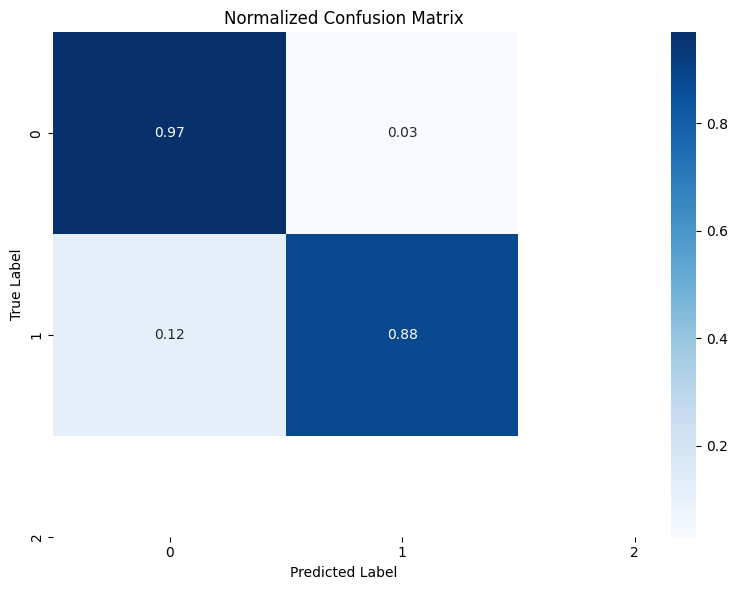

In [121]:

# Plot confusion matrix with normalized values
cm_normalized = confusion_matrix(match_train_dat_label, y_pred, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

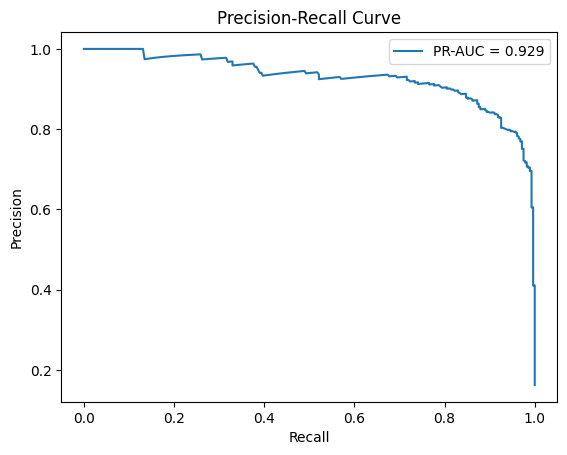

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(match_train_dat_label, y_pred_prob)

# Compute PR-AUC
pr_auc = auc(recall, precision)

# Plot PR curve
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [91]:
y_pred_prob.shape

(1227, 1)

In [118]:
np.sum(all_non_match_and_match_from_Apexigen_label)

282.0

In [123]:
model_10X_all_data.save_weights("./Apexigen_model_10X_all_data_weight_IEDB_McPAS_VDJdb_085_acc_040726.h5")

In [ ]:
model_10X_all_data.load_weights("./Apexigen_model_10X_all_data_weight_IEDB_McPAS_VDJdb_085_acc_040726.h5")

In [124]:
Apexigen_pred_res_train_all = model_10X_all_data.predict(inferencce_input_norm)

583752/583752 [==============================] - 324s 554us/step


(array([12138946.,  1918197.,   889395.,   557220.,   398842.,   307989.,
          250210.,   210609.,   182608.,   161420.,   146583.,   134011.,
          124813.,   118000.,   112624.,   107746.,   104112.,    99117.,
           93049.,    86281.,    79307.,    71742.,    66018.,    62261.,
           58922.,    55608.,    51387.,    45431.,    33914.,    13680.]),
 array([1.71753143e-07, 3.32694761e-02, 6.65387809e-02, 9.98080820e-02,
        1.33077383e-01, 1.66346699e-01, 1.99616000e-01, 2.32885301e-01,
        2.66154617e-01, 2.99423903e-01, 3.32693219e-01, 3.65962505e-01,
        3.99231821e-01, 4.32501137e-01, 4.65770423e-01, 4.99039739e-01,
        5.32309055e-01, 5.65578341e-01, 5.98847628e-01, 6.32116973e-01,
        6.65386260e-01, 6.98655546e-01, 7.31924891e-01, 7.65194178e-01,
        7.98463464e-01, 8.31732750e-01, 8.65002096e-01, 8.98271382e-01,
        9.31540668e-01, 9.64810014e-01, 9.98079300e-01]),
 <BarContainer object of 30 artists>)

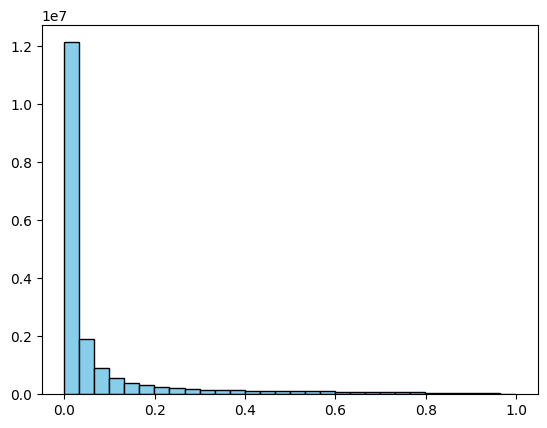

In [125]:
plt.hist(Apexigen_pred_res_train_all, bins=30, color='skyblue', edgecolor='black')

In [126]:
Apexigen_pred_res_train_all_df = pd.DataFrame(Apexigen_pred_res_train_all)

In [127]:
Apexigen_pred_res_train_all_df.columns = ['score']

In [128]:
Apexigen_pred_res_train_all_df[Apexigen_pred_res_train_all_df['score'] > 0.5]

,score
7,0.564534
10,0.892789
28,0.578623
36,0.590237
43,0.564591
...,...
18679889,0.670393
18679911,0.626684
18679922,0.767266
18679938,0.700881


In [129]:
Apexigen_pred_res_train_all_df.columns = ['predicted_binding_probability']
Apexigen_pred_res_train_all_df_significant = Apexigen_pred_res_train_all_df[Apexigen_pred_res_train_all_df['predicted_binding_probability']>=0.5]
Apexigen_pred_res_train_all_df_significant

,predicted_binding_probability
7,0.564534
10,0.892789
28,0.578623
36,0.590237
43,0.564591
...,...
18679889,0.670393
18679911,0.626684
18679922,0.767266
18679938,0.700881


In [130]:
Apexigen_tumor_paired_train_all = pd.concat([repeated_Apexigen_meta, repeated_IEDB_tumor_epitope, Apexigen_pred_res_train_all_df], axis=1)
Apexigen_tumor_paired_train_all

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability
0,4,1756.0,627,PD,05,pathCR,05_post,post_CD40,7.470794,0.032460,3,CD4T_naive,CD4T_naive3,CD4T_naive2,CD4T_naive,CASSVATAGGIGYTF,CAMREGWNTGTASKLTF,SLLMWITQC,0.428897
1,4,1787.0,707,PD,05,pathCR,05_post,post_CD40,7.488294,0.029659,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLGGVNTGELFF,CAASTGNDMRF,AAGIGILTV,0.036122
2,6,1825.0,864,HD,HD_01,HD,HD_03,NaN,7.509335,0.055342,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSQGGLGLGGAVQPQHF,CAAGSGATNKLIF,ELAGIGILTV,0.212221
3,8,974.0,470,PD,01,nopathCR,01_LTF2,follow_up,6.881412,0.075975,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSRLAEVNEQFF,CAESRSGGSYIPTF,YLEPGPVTV,0.004628
4,3,2800.0,865,PD,04,pathCR,04_surgery,surgery,7.937375,0.024286,7,CD4T_naive,CD4T_naive3,CD4T_naive3,CD4T_naive,CASSAGGARVSYEQYF,CAVFSGSRLTF,YLEPGAVTA,0.373498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18680037,0,4706.0,1357,PD,05,pathCR,05_post,post_CD40,8.456594,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSLDSYGYTF,CAVNMDRGSTLGRLYF,QLCDVMFYL,0.010708
18680038,0,2891.0,1380,PD,05,pathCR,05_post,post_CD40,7.969358,0.000000,3,CD8_Tcell,CD8T_GrK,CD8T_GrH,CD8_T,CASSLSYSEETQYF,CLVGERGSTLGRLYF,YLYDRLLRV,0.002353
18680039,0,3474.0,1338,PD,05,pathCR,05_post,post_CD40,8.153062,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASTQNGGDTQYF,CAVTLGGSYIPTF,LYPEFIASI,0.111599
18680040,0,4632.0,1231,PD,05,pathCR,05_post,post_CD40,8.440744,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSNVRRSRDSPLHF,CAIRDGGAQKLVF,MLIGIPVYV,0.009577


In [131]:
Apexigen_tumor_paired_train_all['TCR_Epitope_pair'] = Apexigen_tumor_paired_train_all['TRB_cdr3'] + '_' + Apexigen_tumor_paired_train_all['Epitope']
Apexigen_tumor_paired_train_all[Apexigen_tumor_paired_train_all.TCR_Epitope_pair.isin(Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope.TCR_Epitope_pair.values)]

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
1526,17,1890.0,715,PD,01,nopathCR,01_LTF2,follow_up,7.544332,0.095238,7,CD4T_naive,CD4T_naive2,CD4T_naive3,CD4T_naive,CASSIRSAYEQYF,CAGAGGSSNTGKLIF,GILGFVFTL,0.472034,CASSIRSAYEQYF_GILGFVFTL
1543,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,TPRVTGGGAM,0.547124,CASSPSRNTEAFF_TPRVTGGGAM
118541,38,3612.0,1457,CR,03,pathCR,03_surgery,surgery,8.192017,0.041805,12,CD8T,CD8T_GrH1,CD8T_prolif,CD8_T,CATSREGGETQYF,CATERDFGNEKLTF,FRCPRRFCF,0.876061,CATSREGGETQYF_FRCPRRFCF
138116,0,5787.0,1960,NaN,02,pathCR,02_post,post_CD40,8.663369,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,0.336729,CASSGDGMNTEAFF_FLYALALLL
164403,17,1102.0,638,PD,01,nopathCR,01_LTF2,follow_up,7.004882,0.017241,0,CD8T,CD8T_GrH2,CD8_GrH,CD8_T,CASSPSRNTEAFF,CAASIGNFGNEKLTF,RPHERNGFTVL,0.450946,CASSPSRNTEAFF_RPHERNGFTVL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18306508,9,1581.0,758,PD,01,nopathCR,01_pre,pre_CD40,7.365813,0.067046,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSYSSGELFF,CALSEAGYSGYALNF,LPRRSGAAGA,0.739088,CASSYSSGELFF_LPRRSGAAGA
18322566,6,1836.0,726,HD,HD_01,HD,HD_03,NaN,7.515345,0.053922,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWKASGNTIYF,CAFMKHVASGGSNYKLTF,LPRRSGAAGA,0.734847,CAWKASGNTIYF_LPRRSGAAGA
18413179,0,1981.0,995,CR,03,pathCR,03_pre,pre_CD40,7.591357,0.000000,3,CD8_Tcell,CD8T_GrH,CD8T_GrH,CD8_T,CASSLRGYEQYF,CALLTQGGSEKLVF,LPRRSGAAGA,0.975458,CASSLRGYEQYF_LPRRSGAAGA
18448736,0,1691.0,879,PD,04,pathCR,04_post,post_CD40,7.433075,0.000000,10,CD4_Tcell,CD4T_CXCL13,CD4_Tfh-like,CD4_T,CASSLASTDTQYF,CVVRGTGGRRALTF,LPRRSGAAGA,0.979700,CASSLASTDTQYF_LPRRSGAAGA


In [132]:
Apexigen_tumor_paired_train_all_match_res = Apexigen_tumor_paired_train_all[Apexigen_tumor_paired_train_all.TCR_Epitope_pair.isin(Apexigen_exact_match_IEDB_McPAS_VDJdb_epitope.TCR_Epitope_pair.values)].sort_values(['predicted_binding_probability'])
Apexigen_tumor_paired_train_all_match_res

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
12763056,0,2444.0,1136,CR,03,pathCR,03_pre,pre_CD40,7.801391,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSVVGGDEQYF,CAAWLGGAGSYQLTF,GLCTLVAML,0.026631,CASSVVGGDEQYF_GLCTLVAML
16668739,0,4774.0,2013,PD,01,nopathCR,01_pre,pre_CD40,8.470940,0.000000,3,T/NK,Teff/NK,CD8T_GrH,CD8_T,CASSFEETQYF,CAVSNDYKLSF,TAAQAAVVRFQEAAN,0.079082,CASSFEETQYF_TAAQAAVVRFQEAAN
11090757,0,3028.0,1295,PD,05,pathCR,05_post,post_CD40,8.015657,0.000000,2,Treg,Treg,Treg1,Treg,CASSYPNQPQHF,CAASDRGSQGNLIF,LLWNGPMAV,0.143726,CASSYPNQPQHF_LLWNGPMAV
15275502,0,6857.0,2166,PD,05,pathCR,05_pre,pre_CD40,8.833025,0.000000,4,CD8_Tcell,CD8T_prolif,CD8T_GrB,CD8_T,CASSSTDTQYF,CVVSENPDSGYALNF,VISNDVCAQV,0.156714,CASSSTDTQYF_VISNDVCAQV
2418782,0,7633.0,2263,PD,01,nopathCR,01_pre,pre_CD40,8.940236,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSTLAGGTDTQYF,CAVGANYGQNFVF,LLAGIGTVPI,0.159820,CASSTLAGGTDTQYF_LLAGIGTVPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12450014,0,4783.0,1748,NaN,02,pathCR,02_post,post_CD40,8.472823,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVENTGGFKTIF,FLYALALLL,0.980757,CASSGDGMNTEAFF_FLYALALLL
13084305,0,5933.0,2036,NaN,02,pathCR,02_post,post_CD40,8.688285,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,0.981446,CASSGDGMNTEAFF_FLYALALLL
17445111,27,3027.0,931,PD,01,nopathCR,01_post,post_CD40,8.015327,0.052527,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSLGGNQPQHF,CAYRSGNDMRF,LPRRSGAAGA,0.981778,CASSLGGNQPQHF_LPRRSGAAGA
10061872,0,4635.0,1935,PD,04,pathCR,04_post,post_CD40,8.441392,0.000000,4,CD8_Tcell,CD8T_GrH,CD8T_GrB,CD8_T,CASSLGGSYEQYF,CAYRTPLPSPGGTYKYIF,LPRRSGAAGA,0.987907,CASSLGGSYEQYF_LPRRSGAAGA


In [133]:
Apexigen_tumor_paired_train_all_match_res[Apexigen_tumor_paired_train_all_match_res['predicted_binding_probability'] > 0.5]

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
10965322,48,2450.0,813,PD,04,pathCR,04_pre,pre_CD40,7.803844,0.044490,3,CD4T_naive,CD4T_naive1,CD4T_naive2,CD4T_naive,CASSPGQGNQPQHF,CASDNDMRF,ELAGIGILTV,0.500769,CASSPGQGNQPQHF_ELAGIGILTV
11881054,0,4641.0,1494,PD,01,nopathCR,01_pre,pre_CD40,8.442685,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSPRTSGSYEQYF,CAVNGWANAGKSTF,RFYKTLRAEQASQ,0.523569,CASSPRTSGSYEQYF_RFYKTLRAEQASQ
7086633,22,1856.0,790,PD,05,pathCR,05_pre,pre_CD40,7.526179,0.070043,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASSLSYEQYF,CAANQDYGQNFVF,FLTVFSHFM,0.530280,CASSLSYEQYF_FLTVFSHFM
11893811,53,995.0,555,HD,HD_03,HD,HD_01,NaN,6.902743,0.037186,10,Treg,Treg,Treg,Treg,CASSRGLQETQYF,CAESPMDSSYKLIF,FLNVLFPLL,0.535962,CASSRGLQETQYF_FLNVLFPLL
7243840,0,5263.0,2081,PD,04,pathCR,04_post,post_CD40,8.568457,0.000000,2,CD4_Tcell,CD4T_CXCL13,Treg1,Treg,CASSPEETQYF,CAALNGGYNKLIF,TAAQAAVVRFQEAAN,0.539783,CASSPEETQYF_TAAQAAVVRFQEAAN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12450014,0,4783.0,1748,NaN,02,pathCR,02_post,post_CD40,8.472823,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVENTGGFKTIF,FLYALALLL,0.980757,CASSGDGMNTEAFF_FLYALALLL
13084305,0,5933.0,2036,NaN,02,pathCR,02_post,post_CD40,8.688285,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,0.981446,CASSGDGMNTEAFF_FLYALALLL
17445111,27,3027.0,931,PD,01,nopathCR,01_post,post_CD40,8.015327,0.052527,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSLGGNQPQHF,CAYRSGNDMRF,LPRRSGAAGA,0.981778,CASSLGGNQPQHF_LPRRSGAAGA
10061872,0,4635.0,1935,PD,04,pathCR,04_post,post_CD40,8.441392,0.000000,4,CD8_Tcell,CD8T_GrH,CD8T_GrB,CD8_T,CASSLGGSYEQYF,CAYRTPLPSPGGTYKYIF,LPRRSGAAGA,0.987907,CASSLGGSYEQYF_LPRRSGAAGA


In [134]:
Apexigen_tumor_paired_train_all_match_res.drop_duplicates()

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
12763056,0,2444.0,1136,CR,03,pathCR,03_pre,pre_CD40,7.801391,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSVVGGDEQYF,CAAWLGGAGSYQLTF,GLCTLVAML,0.026631,CASSVVGGDEQYF_GLCTLVAML
16668739,0,4774.0,2013,PD,01,nopathCR,01_pre,pre_CD40,8.470940,0.000000,3,T/NK,Teff/NK,CD8T_GrH,CD8_T,CASSFEETQYF,CAVSNDYKLSF,TAAQAAVVRFQEAAN,0.079082,CASSFEETQYF_TAAQAAVVRFQEAAN
11090757,0,3028.0,1295,PD,05,pathCR,05_post,post_CD40,8.015657,0.000000,2,Treg,Treg,Treg1,Treg,CASSYPNQPQHF,CAASDRGSQGNLIF,LLWNGPMAV,0.143726,CASSYPNQPQHF_LLWNGPMAV
15275502,0,6857.0,2166,PD,05,pathCR,05_pre,pre_CD40,8.833025,0.000000,4,CD8_Tcell,CD8T_prolif,CD8T_GrB,CD8_T,CASSSTDTQYF,CVVSENPDSGYALNF,VISNDVCAQV,0.156714,CASSSTDTQYF_VISNDVCAQV
2418782,0,7633.0,2263,PD,01,nopathCR,01_pre,pre_CD40,8.940236,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CASSTLAGGTDTQYF,CAVGANYGQNFVF,LLAGIGTVPI,0.159820,CASSTLAGGTDTQYF_LLAGIGTVPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12450014,0,4783.0,1748,NaN,02,pathCR,02_post,post_CD40,8.472823,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVENTGGFKTIF,FLYALALLL,0.980757,CASSGDGMNTEAFF_FLYALALLL
13084305,0,5933.0,2036,NaN,02,pathCR,02_post,post_CD40,8.688285,0.000000,6,CD8_Tcell,CD8T_GrK,CD8T_GrK,CD8_T,CASSGDGMNTEAFF,CAVLMDSNYQLIW,FLYALALLL,0.981446,CASSGDGMNTEAFF_FLYALALLL
17445111,27,3027.0,931,PD,01,nopathCR,01_post,post_CD40,8.015327,0.052527,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CASSLGGNQPQHF,CAYRSGNDMRF,LPRRSGAAGA,0.981778,CASSLGGNQPQHF_LPRRSGAAGA
10061872,0,4635.0,1935,PD,04,pathCR,04_post,post_CD40,8.441392,0.000000,4,CD8_Tcell,CD8T_GrH,CD8T_GrB,CD8_T,CASSLGGSYEQYF,CAYRTPLPSPGGTYKYIF,LPRRSGAAGA,0.987907,CASSLGGSYEQYF_LPRRSGAAGA


In [135]:
Apexigen_tumor_paired_train_all_match_res.drop_duplicates().to_csv("Apexigen_tumor_paired_train_all_match_res_IEDB_McPAS_VDJdb_085_acc_040726.csv")

In [136]:
Apexigen_tumor_paired_train_all[Apexigen_tumor_paired_train_all.predicted_binding_probability > 0.8]

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
10,7,1361.0,628,CR,03,pathCR,03_LTF2,follow_up,7.215975,0.022777,2,CD4T_naive,CD4T_naive1,CD4T_naive1,CD4T_naive,CASIISGVGTDTQYF,CAVSATNKLIF,SLLMWITQV,0.892789,CASIISGVGTDTQYF_SLLMWITQV
66,6,1463.0,623,HD,HD_01,HD,HD_03,NaN,7.288244,0.058100,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWTVAGADEQYF,CAMRRLSNYQLIW,SLLMWITQA,0.920082,CAWTVAGADEQYF_SLLMWITQA
75,8,4581.0,1390,PD,01,nopathCR,01_LTF2,follow_up,8.429672,0.067671,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSFRTEGGELFF,CAASSTTSGSRLTF,ELGGIGILTV,0.848319,CASSFRTEGGELFF_ELGGIGILTV
87,2,1610.0,586,CR,03,pathCR,03_pre,pre_CD40,7.383989,0.046584,2,CD4T_naive,CD4T_naive3,CD4T_naive1,CD4T_naive,CSARVPRDEKLFF,CALSGRFSDGQKLLF,FLKGIGWIPI,0.803926,CSARVPRDEKLFF_FLKGIGWIPI
200,0,2920.0,939,PD,01,nopathCR,01_pre,pre_CD40,7.979339,0.038356,2,Treg,Treg,CD4T_naive1,CD4T_naive,CSARGQAETQYF,CAVKPVGFGNVLHC,KPILWRGLK,0.925428,CSARGQAETQYF_KPILWRGLK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18679351,0,3296.0,1274,PD,05,pathCR,05_pre,pre_CD40,8.100465,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CSAIHPGTGGNEQFF,CAADHFGNEKLTF,ILTGLNYEA,0.936056,CSAIHPGTGGNEQFF_ILTGLNYEA
18679526,0,2547.0,1124,PD,05,pathCR,05_pre,pre_CD40,7.842671,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CSAPSGRARDTQYF,CALSDQGSARQLTF,TLFTMVGTV,0.868014,CSAPSGRARDTQYF_TLFTMVGTV
18679571,0,2523.0,984,PD,05,pathCR,05_pre,pre_CD40,7.833204,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CSAGGGVIYGYTF,CAGAKGSQGNLIF,SLLLLSVSV,0.929808,CSAGGGVIYGYTF_SLLLLSVSV
18679644,0,1927.0,943,PD,05,pathCR,05_pre,pre_CD40,7.563720,0.000000,6,CD8_Tcell,CD8T_GrH,CD8T_GrK,CD8_T,CASSRGGGFTDTQYF,CKLQLLNLETQLSTFVQRLPIL,FSWGAEGQRPGF,0.885452,CASSRGGGFTDTQYF_FSWGAEGQRPGF


In [137]:
Apexigen_tumor_paired_train_all[Apexigen_tumor_paired_train_all.predicted_binding_probability > 0.9]

,batch,n_counts,n_genes,outcome,patient,response,sample,timepoint,log_counts,mt_frac,scvi_r1,cell_class,cell_type,cell_type_scvi,cell_class_scvi,TRB_cdr3,TRA_cdr3,Epitope,predicted_binding_probability,TCR_Epitope_pair
66,6,1463.0,623,HD,HD_01,HD,HD_03,NaN,7.288244,0.058100,3,CD4T_naive,CD4T_naive2,CD4T_naive2,CD4T_naive,CAWTVAGADEQYF,CAMRRLSNYQLIW,SLLMWITQA,0.920082,CAWTVAGADEQYF_SLLMWITQA
200,0,2920.0,939,PD,01,nopathCR,01_pre,pre_CD40,7.979339,0.038356,2,Treg,Treg,CD4T_naive1,CD4T_naive,CSARGQAETQYF,CAVKPVGFGNVLHC,KPILWRGLK,0.925428,CSARGQAETQYF_KPILWRGLK
400,2,1435.0,703,CR,03,pathCR,03_pre,pre_CD40,7.268920,0.043902,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CARGSCNEQFF,CALSEARAYNTDKLIF,FRCPRRFCF,0.921755,CARGSCNEQFF_FRCPRRFCF
507,3,533.0,380,PD,04,pathCR,04_surgery,surgery,6.278522,0.043152,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CSVRGGLAGGLETQYF,CAFNFGNEKLTF,ALIHHNTYL,0.939872,CSVRGGLAGGLETQYF_ALIHHNTYL
544,4,1701.0,824,PD,05,pathCR,05_post,post_CD40,7.438972,0.074074,0,CD8T,CD8T_GrH1,CD8_GrH,CD8_T,CASSPPSGSYEQYF,CAVDGFNKFYF,AVYDGREHTV,0.962254,CASSPPSGSYEQYF_AVYDGREHTV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18678606,0,1919.0,1035,PD,05,pathCR,05_pre,pre_CD40,7.559559,0.000000,1,CD8_Tcell,CD8T_GrK,CD4_Tnaive1,CD4_T,CSARDLRGTSPNEQFF,CAVWAGGTSYGKLTF,IVDQVPFSV,0.949027,CSARDLRGTSPNEQFF_IVDQVPFSV
18678961,0,13113.0,3088,PD,05,pathCR,05_pre,pre_CD40,9.481359,0.000000,15,Treg,Treg,Treg2,Treg,CSARPEPAGKQFF,CAASIQAGTALIF,SLLMWITQA,0.954384,CSARPEPAGKQFF_SLLMWITQA
18679295,0,2041.0,885,PD,05,pathCR,05_pre,pre_CD40,7.621195,0.000000,3,CD8_Tcell,CD8T_mem,CD8T_GrH,CD8_T,CSARDPRGHEQFF,CAASYYNQGGKLIF,FRCPRRFCF,0.946521,CSARDPRGHEQFF_FRCPRRFCF
18679351,0,3296.0,1274,PD,05,pathCR,05_pre,pre_CD40,8.100465,0.000000,1,CD4_Tcell,CD4T_naive,CD4_Tnaive1,CD4_T,CSAIHPGTGGNEQFF,CAADHFGNEKLTF,ILTGLNYEA,0.936056,CSAIHPGTGGNEQFF_ILTGLNYEA


In [146]:
Apexigen_tumor_paired_train_all.shape

(18680042, 20)

In [147]:
Apexigen_tumor_paired_train_all.to_csv("Apexigen_tumor_paired_train_all_pred_res_IEDB_McPAS_VDJdb_085_acc_040726.csv")

In [109]:
Apexigen_tumor_paired_train_all = pd.read_csv("Apexigen_tumor_paired_train_all_pred_res_IEDB_McPAS_VDJdb_082_acc.csv", index_col=0)

In [110]:
Apexigen_tumor_paired_train_all.shape

(18680042, 20)

In [ ]:
Apexigen_tumor_paired_train_all[Apexigen_tumor_paired_train_all['predicted_binding_probability'] > 0.5]

In [ ]:
# Apexigen_tumor_paired_train_all.to_csv("Apexigen_tumor_paired_train_all_pred_res_031126.csv")

In [ ]:
# Apexigen_tumor_paired_train_all[Apexigen_tumor_paired_train_all.TCR_Epitope_pair.isin(Apexigen_exact_match_IEDB_epitope.TCR_Epitope_pair.values)].to_csv("Apexigen_tumor_paired_matching_with_IEDB_scores_031726_85acc.csv")

## More about biology

In [ ]:
adata = sc.read_h5ad('./Apexigen_data/Apexigen_gene_TCR_annotated_for_integration_real_case.h5ad')

In [ ]:
adata

In [ ]:
ED_integration_gex_tcr_df = pd.DataFrame(np.load(f"ED_integration_batch_gex_tcr_embeddings_train_Apexigen.npy" ))
ED_integration_gex_tcr_df

In [ ]:
import anndata as ad

In [ ]:
Apexigen_emb = ad.AnnData(ED_integration_gex_tcr_df, obs=adata.obs)
Apexigen_emb

In [ ]:
sc.tl.pca(Apexigen_emb,svd_solver='arpack')
sc.pp.neighbors(Apexigen_emb, n_neighbors = 15, n_pcs=45)
sc.tl.leiden(Apexigen_emb, resolution=0.3)

In [ ]:
sc.tl.umap(Apexigen_emb)
sc.pl.umap(Apexigen_emb, color=['leiden'])

In [ ]:
Apexigen_emb.obs['sample'].value_counts()


In [ ]:
Apexigen_emb_no_HC = Apexigen_emb[~Apexigen_emb.obs['sample'].str.contains("HD")].copy()

In [ ]:
Apexigen_emb_no_HC.obs['sample'].value_counts()

In [ ]:
sc.pl.umap(Apexigen_emb_no_HC, color=['cell_class_scvi'])

In [ ]:
sc.pl.umap(Apexigen_emb_no_HC, color=['timepoint','patient'])

In [ ]:
sc.pl.umap(Apexigen_emb_no_HC, color=['response'])


In [ ]:
sc.pp.highly_variable_genes(adata)

In [ ]:
adata_HVG = adata[:,adata.var['highly_variable']]
adata_HVG

In [ ]:
adata_HVG.X[:100,:100].toarray()

In [ ]:
sc.pp.pca(adata_HVG)

In [ ]:
sc.pp.neighbors(adata_HVG, n_neighbors = 15, n_pcs=45)
sc.tl.leiden(adata_HVG, resolution=0.3)
sc.tl.umap(adata_HVG)
sc.pl.umap(adata_HVG, color=['leiden'])

In [ ]:
adata_HVG_no_HC = adata_HVG[~adata_HVG.obs['sample'].str.contains("HD")].copy()

In [ ]:
sc.pl.umap(adata_HVG_no_HC, color=['timepoint','patient'])

In [ ]:
sc.pp.log1p(adata_HVG_no_HC)

In [ ]:
sc.pp.pca(adata_HVG_no_HC, svd_solver="arpack", use_highly_variable=True)

In [ ]:
Apexigen_tumor_paired_train_all = pd.read_csv("Apexigen_tumor_paired_train_all_pred_res_IEDB_McPAS_VDJdb.csv", index_col=0)

In [ ]:
Apexigen_tumor_paired_train_all